In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import os
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
import warnings
warnings.filterwarnings('ignore')

# set display options and theme for seaborn
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 100})


**Nguồn dữ liệu**: UCI Machine Learning Repository [link](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset/data)
- **Số mẫu**: ~30,000 người trưởng thành
- **Số đặc tính**: 15 biến
- **Biến mục tiêu**: income (<=50K hoặc >50K)

In [29]:
df = pd.read_csv('adult.csv')
print(df[0:1000]) 
print(df.columns)
# df.info()
# df.head()

     age  workclass  fnlwgt     education  educational-num  \
0     25    Private  226802          11th                7   
1     38    Private   89814       HS-grad                9   
2     28  Local-gov  336951    Assoc-acdm               12   
3     44    Private  160323  Some-college               10   
4     18          ?  103497  Some-college               10   
..   ...        ...     ...           ...              ...   
995   17    Private   28544          11th                7   
996   59  Local-gov  662460          10th                6   
997   22    Private  152328  Some-college               10   
998   40    Private  120277     Bachelors               13   
999   36    Private  180278     Bachelors               13   

         marital-status         occupation   relationship   race  gender  \
0         Never-married  Machine-op-inspct      Own-child  Black    Male   
1    Married-civ-spouse    Farming-fishing        Husband  White    Male   
2    Married-civ-spouse    

In [30]:
df.describe()
df.isnull().sum() * 100

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [31]:
cols = df.select_dtypes(include='object').columns.tolist()
for col in cols:
    print(f'{col}: {df[col].unique()}')

workclass: <StringArray>
[         'Private',        'Local-gov',                '?',
 'Self-emp-not-inc',      'Federal-gov',        'State-gov',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str
education: <StringArray>
[        '11th',      'HS-grad',   'Assoc-acdm', 'Some-college',
         '10th',  'Prof-school',      '7th-8th',    'Bachelors',
      'Masters',    'Doctorate',      '5th-6th',    'Assoc-voc',
          '9th',         '12th',      '1st-4th',    'Preschool']
Length: 16, dtype: str
marital-status: <StringArray>
[        'Never-married',    'Married-civ-spouse',               'Widowed',
              'Divorced',             'Separated', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str
occupation: <StringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
                 '?',     'Other-service',    'Prof-specialty',
      'Craft-repair',      'Adm-clerical',   'Exec-managerial',
      'Tech-su

In [32]:
cols_clean = ['workclass', 'occupation', 'native-country']
for col in cols_clean:
    df[col] = df[col].replace('?', df[col].mode()[0])
for col in cols_clean:
    print(f'{col}: {df[col].unique()}')

workclass: <StringArray>
[         'Private',        'Local-gov', 'Self-emp-not-inc',
      'Federal-gov',        'State-gov',     'Self-emp-inc',
      'Without-pay',     'Never-worked']
Length: 8, dtype: str
occupation: <StringArray>
['Machine-op-inspct',   'Farming-fishing',   'Protective-serv',
    'Prof-specialty',     'Other-service',      'Craft-repair',
      'Adm-clerical',   'Exec-managerial',      'Tech-support',
             'Sales',   'Priv-house-serv',  'Transport-moving',
 'Handlers-cleaners',      'Armed-Forces']
Length: 14, dtype: str
native-country: <StringArray>
[             'United-States',                       'Peru',
                  'Guatemala',                     'Mexico',
         'Dominican-Republic',                    'Ireland',
                    'Germany',                'Philippines',
                   'Thailand',                      'Haiti',
                'El-Salvador',                'Puerto-Rico',
                    'Vietnam',                

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [34]:
df['age'] = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)

df_clean = df.copy()

df_clean['income'] = df_clean['income'].str.strip().str.replace('.', '', regex=False)
print("✅ Giá trị income:", df_clean['income'].unique())

if 'educational-num' in df_clean.columns:
    df_clean.rename(columns={'educational-num': 'education-num'}, inplace=True)
elif 'education.num' in df_clean.columns:
    df_clean.rename(columns={'education.num': 'education-num'}, inplace=True)
# Nếu cột đã tên đúng thì bỏ qua
print(f"\n✅ Dữ liệu sau làm sạch: {df_clean.shape}")
print(df_clean.head())

✅ Giá trị income: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

✅ Dữ liệu sau làm sạch: (48842, 15)
    age  workclass  fnlwgt     education  education-num      marital-status  \
0  25.0    Private  226802          11th              7       Never-married   
1  38.0    Private   89814       HS-grad              9  Married-civ-spouse   
2  28.0  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3  44.0    Private  160323  Some-college             10  Married-civ-spouse   
4  18.0    Private  103497  Some-college             10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4     Prof-speci

In [35]:
dropout_levels = ['Preschool', '10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th']
# for level in dropout_levels:
df_clean['education'] = df_clean['education'].replace(dropout_levels, 'Dropout')

df_clean['education'] = df_clean['education'].replace(['HS-Grad', 'HS-grad'], 'HighGrad')
df_clean['education'] = df_clean['education'].replace(['Some-college', 'Assoc-acdm', 'Assoc-voc'], 'CommunityCollege')
df_clean['education'] = df_clean['education'].replace(['Prof-school'], 'Masters')
print(df_clean['education'].value_counts())

education
HighGrad            15784
CommunityCollege    14540
Bachelors            8025
Dropout              6408
Masters              3491
Doctorate             594
Name: count, dtype: int64


In [36]:
df_clean['marital-status'] = df_clean['marital-status'].replace('Never-married', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(['Married-AF-spouse', 'Married-civ-spouse'], 'Married')
df_clean['marital-status'] = df_clean['marital-status'].replace('Married-spouse-absent', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(['Separated', 'Divorced'], 'Separated')

print(df_clean['marital-status'].value_counts())
df.T

marital-status
Married       22416
NotMarried    16745
Separated      8163
Widowed        1518
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,48832,48833,48834,48835,48836,48837,48838,48839,48840,48841
age,25.0,38.0,28.0,44.0,18.0,34.0,29.0,63.0,24.0,55.0,...,32.0,43.0,32.0,53.0,22.0,27.0,40.0,58.0,22.0,52.0
workclass,Private,Private,Local-gov,Private,Private,Private,Private,Self-emp-not-inc,Private,Private,...,Private,Private,Private,Private,Private,Private,Private,Private,Private,Self-emp-inc
fnlwgt,226802,89814,336951,160323,103497,198693,227026,104626,369667,104996,...,34066,84661,116138,321865,310152,257302,154374,151910,201490,287927
education,11th,HS-grad,Assoc-acdm,Some-college,Some-college,10th,HS-grad,Prof-school,Some-college,7th-8th,...,10th,Assoc-voc,Masters,Masters,Some-college,Assoc-acdm,HS-grad,HS-grad,HS-grad,HS-grad
educational-num,7,9,12,10,10,6,9,15,10,4,...,6,11,14,14,10,12,9,9,9,9
marital-status,Never-married,Married-civ-spouse,Married-civ-spouse,Married-civ-spouse,Never-married,Never-married,Never-married,Married-civ-spouse,Never-married,Married-civ-spouse,...,Married-civ-spouse,Married-civ-spouse,Never-married,Married-civ-spouse,Never-married,Married-civ-spouse,Married-civ-spouse,Widowed,Never-married,Married-civ-spouse
occupation,Machine-op-inspct,Farming-fishing,Protective-serv,Machine-op-inspct,Prof-specialty,Other-service,Prof-specialty,Prof-specialty,Other-service,Craft-repair,...,Handlers-cleaners,Sales,Tech-support,Exec-managerial,Protective-serv,Tech-support,Machine-op-inspct,Adm-clerical,Adm-clerical,Exec-managerial
relationship,Own-child,Husband,Husband,Husband,Own-child,Not-in-family,Unmarried,Husband,Unmarried,Husband,...,Husband,Husband,Not-in-family,Husband,Not-in-family,Wife,Husband,Unmarried,Own-child,Wife
race,Black,White,White,Black,White,White,Black,White,White,White,...,Amer-Indian-Eskimo,White,Asian-Pac-Islander,White,White,White,White,White,White,White
gender,Male,Male,Male,Male,Female,Male,Male,Male,Female,Male,...,Male,Male,Male,Male,Male,Female,Male,Female,Male,Female


In [37]:
print("🎯 Tạo đặc tính phân chia (Binned Features) và tương tác...")

df_clean['age_bin']          = pd.cut(df_clean['age'], bins=20)
df_clean['hours-per-week_bin'] = pd.cut(df_clean['hours-per-week'], bins=10)
df_clean['age-hours']        = df_clean['age'] * df_clean['hours-per-week']

print("✅ Các đặc tính tương tác đã được tạo")
print(df_clean[['age_bin','hours-per-week_bin','age-hours']].head(3))


🎯 Tạo đặc tính phân chia (Binned Features) và tương tác...
✅ Các đặc tính tương tác đã được tạo
         age_bin hours-per-week_bin  age-hours
0  (24.3, 27.95]       (30.4, 40.2]     1000.0
1  (35.25, 38.9]       (40.2, 50.0]     1900.0
2  (27.95, 31.6]       (30.4, 40.2]     1120.0


# eda

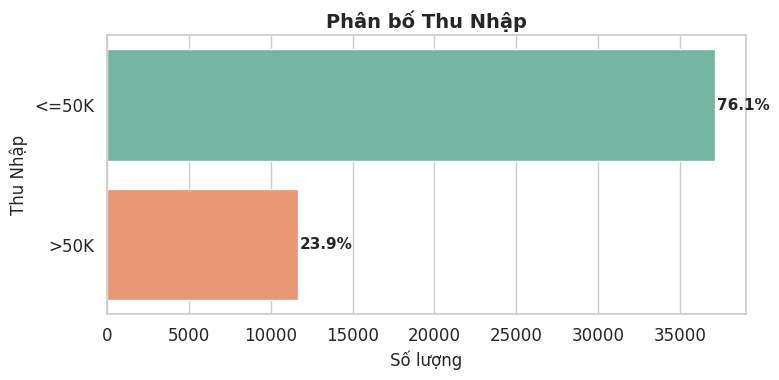

In [38]:
# Phân bố biến mục tiêu
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clean, y='income', palette='Set2', order=df_clean['income'].value_counts().index)
plt.title('Phân bố Thu Nhập', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng', fontsize=12)
plt.ylabel('Thu Nhập', fontsize=12)

# Thêm nhãn phần trăm
total = len(df_clean)
for p in ax.patches:
    pct = f'{100*p.get_width()/total:.1f}%'
    ax.annotate(pct, (p.get_width()+100, p.get_y()+p.get_height()/2),
                va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


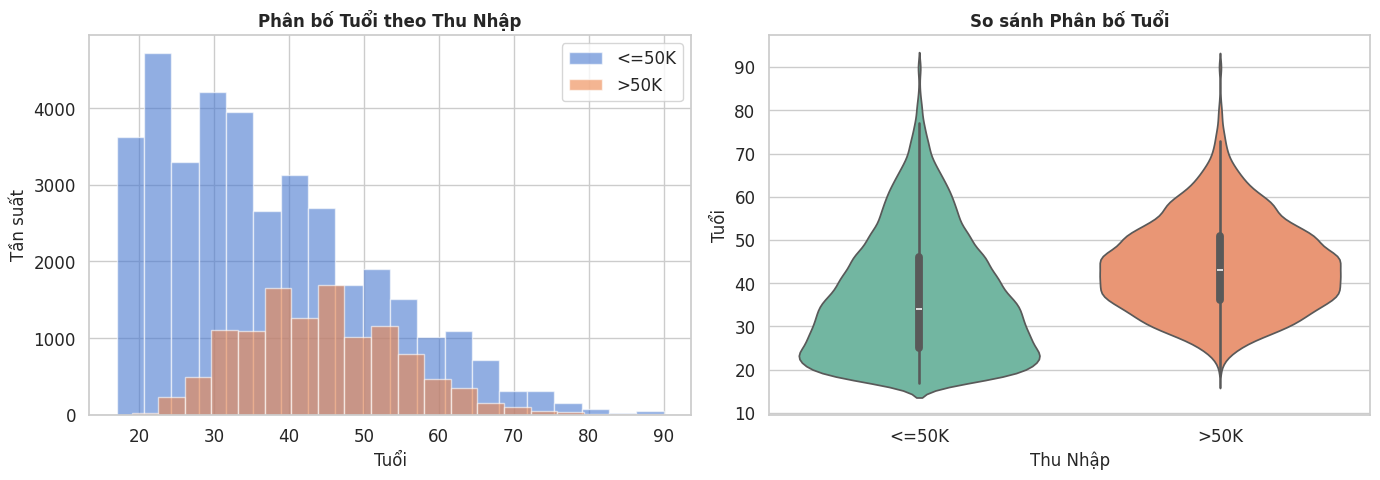

In [39]:
# Phân bố tuổi theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income_val in df_clean['income'].unique():
    data = df_clean[df_clean['income'] == income_val]['age']
    axes[0].hist(data, alpha=0.6, label=income_val, bins=20)
axes[0].set_xlabel('Tuổi', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Tuổi theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()

sns.violinplot(data=df_clean, x='income', y='age', ax=axes[1],
               hue='income', palette='Set2', legend=False)
axes[1].set_title('So sánh Phân bố Tuổi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Tuổi', fontsize=12)

plt.tight_layout()
plt.show()

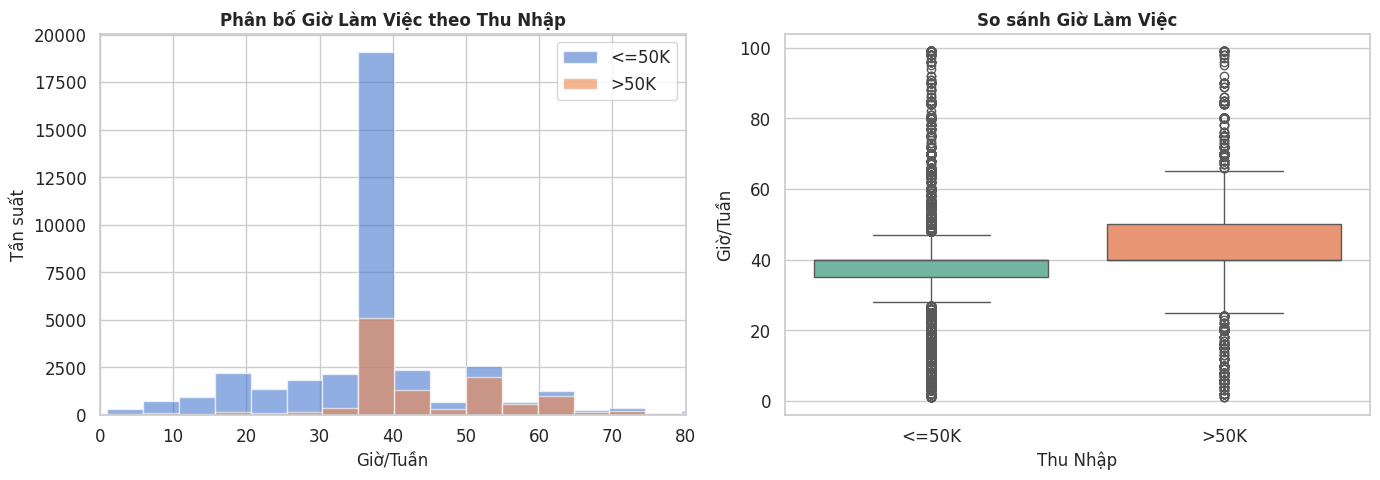

In [40]:
# Giờ làm việc theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income_val in df_clean['income'].unique():
    data = df_clean[df_clean['income'] == income_val]['hours-per-week']
    axes[0].hist(data, alpha=0.6, label=income_val, bins=20)
axes[0].set_xlabel('Giờ/Tuần', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Giờ Làm Việc theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 80)

sns.boxplot(data=df_clean, x='income', y='hours-per-week', ax=axes[1],
            hue='income', palette='Set2', legend=False)
axes[1].set_title('So sánh Giờ Làm Việc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Giờ/Tuần', fontsize=12)

plt.tight_layout()
plt.show()

In [41]:
print("🔹 Lựa chọn và mã hóa đặc tính cho mô hình...")
df_model = df_clean.copy()

le = LabelEncoder()
# this one will be used for all categorical columns, so we can reuse it in the loop
for enc_col in df_model.select_dtypes(include=['object', 'category']).columns:
    # fit_transform sẽ tự động gán số cho từng giá trị duy nhất trong cột, và transform sẽ thay thế giá trị bằng số đó
    df_model[enc_col] = le.fit_transform(df_model[enc_col].astype(str))

print(f"✅ Label Encoding hoàn tất. Shape: {df_model.shape}")
print(df_model.dtypes)
df_model.T

🔹 Lựa chọn và mã hóa đặc tính cho mô hình...
✅ Label Encoding hoàn tất. Shape: (48842, 18)
age                   float64
workclass               int64
fnlwgt                  int64
education               int64
education-num           int64
marital-status          int64
occupation              int64
relationship            int64
race                    int64
gender                  int64
capital-gain            int64
capital-loss            int64
hours-per-week        float64
native-country          int64
income                  int64
age_bin                 int64
hours-per-week_bin      int64
age-hours             float64
dtype: object


,0,1,2,3,4,5,6,7,8,9,...,48832,48833,48834,48835,48836,48837,48838,48839,48840,48841
age,25.0,38.0,28.0,44.0,18.0,34.0,29.0,63.0,24.0,55.0,...,32.0,43.0,32.0,53.0,22.0,27.0,40.0,58.0,22.0,52.0
workclass,3.0,3.0,1.0,3.0,3.0,3.0,3.0,5.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0
fnlwgt,226802.0,89814.0,336951.0,160323.0,103497.0,198693.0,227026.0,104626.0,369667.0,104996.0,...,34066.0,84661.0,116138.0,321865.0,310152.0,257302.0,154374.0,151910.0,201490.0,287927.0
education,3.0,4.0,1.0,1.0,1.0,3.0,4.0,5.0,1.0,3.0,...,3.0,1.0,5.0,5.0,1.0,1.0,4.0,4.0,4.0,4.0
education-num,7.0,9.0,12.0,10.0,10.0,6.0,9.0,15.0,10.0,4.0,...,6.0,11.0,14.0,14.0,10.0,12.0,9.0,9.0,9.0,9.0
marital-status,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,1.0,0.0
occupation,6.0,4.0,10.0,6.0,9.0,7.0,9.0,9.0,7.0,2.0,...,5.0,11.0,12.0,3.0,10.0,12.0,6.0,0.0,0.0,3.0
relationship,3.0,0.0,0.0,0.0,3.0,1.0,4.0,0.0,4.0,0.0,...,0.0,0.0,1.0,0.0,1.0,5.0,0.0,4.0,3.0,5.0
race,2.0,4.0,4.0,2.0,4.0,4.0,2.0,4.0,4.0,4.0,...,0.0,4.0,1.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
gender,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


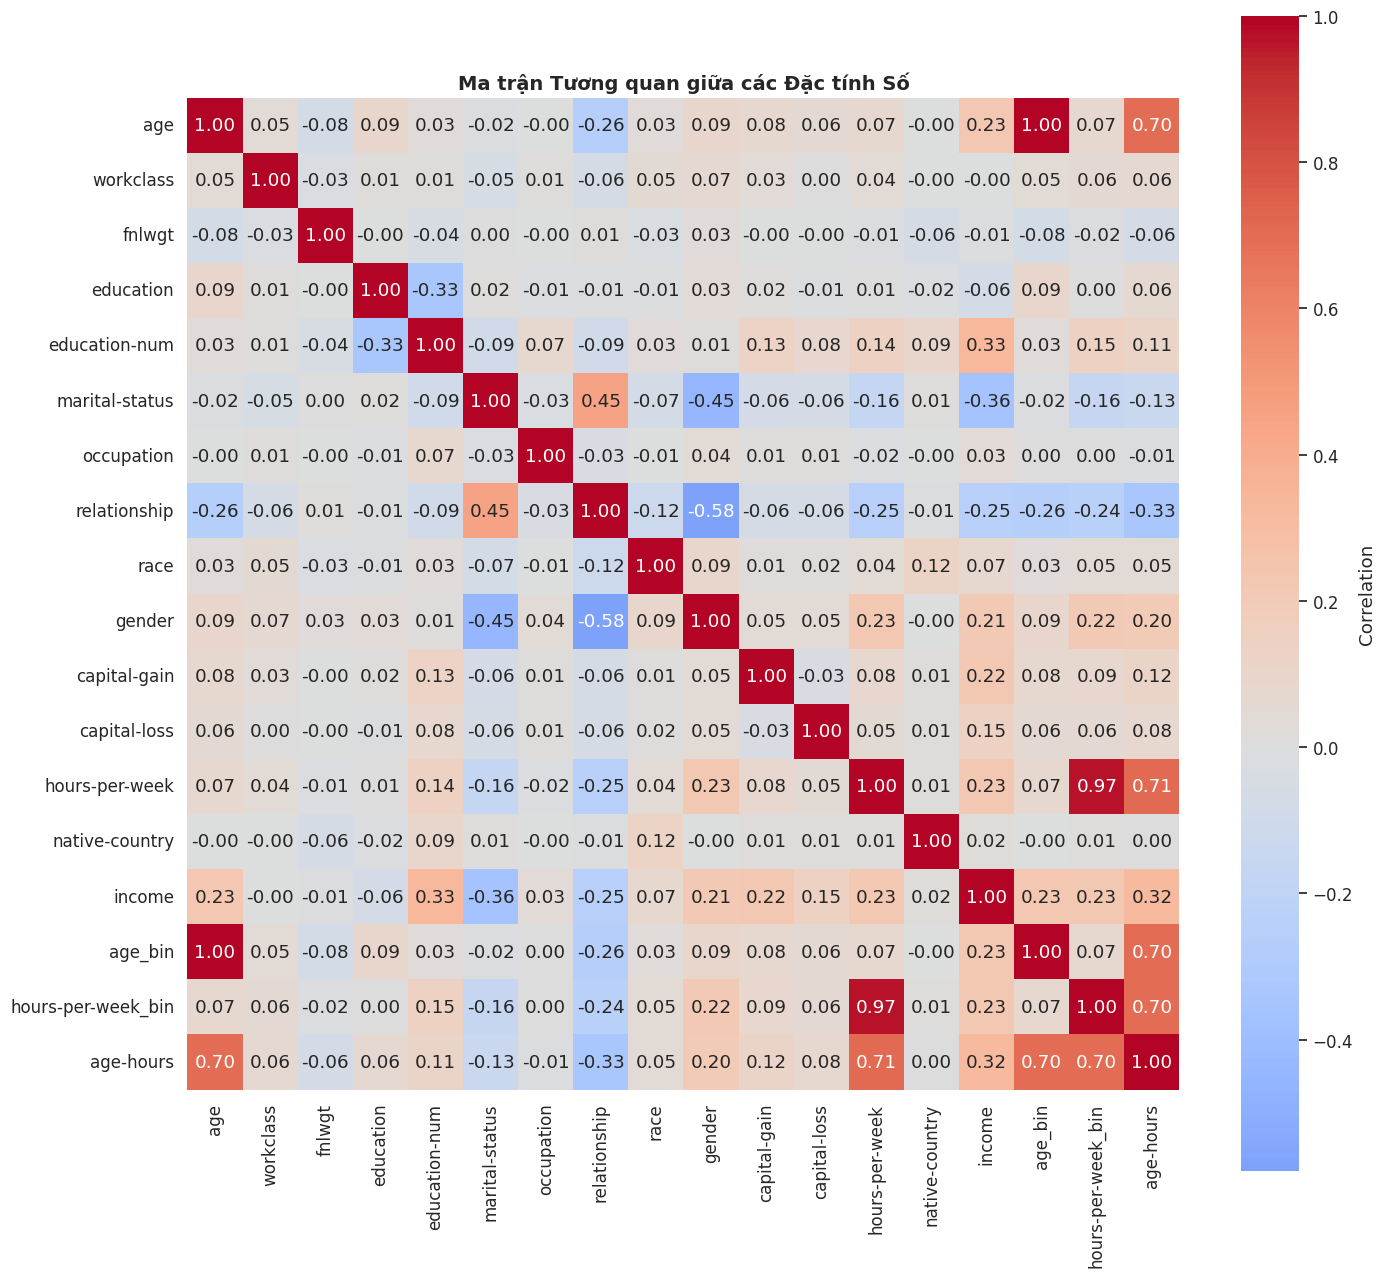

In [42]:
# Ma trận tương quan
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
corr = df_model[numeric_cols].corr()

plt.figure(figsize=(16, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Ma trận Tương quan giữa các Đặc tính Số', fontsize=14, fontweight='bold')
# plt.tight_layout()
plt.show()

In [57]:
# Danh sách các cột thực sự cần loại bỏ khỏi X
drop_cols = ['age_bin', 'hours-per-week_bin','education', 'native-country',"income"]  # 'education-num' đã được đổi tên nếu tồn tại, nên bỏ luôn để tránh nhầm lẫn

X = df_model.drop(columns=drop_cols, errors='ignore')
y = df_model['income']
print(f"📊 Đặc tính sử dụng: {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Training set: {X_train.shape}  ({y_train.value_counts(normalize=True).round(3).to_dict()})")
print(f"📊 Test set    : {X_test.shape}  ({y_test.value_counts(normalize=True).round(3).to_dict()})")

# Chuẩn hóa dữ liệu (cần thiết cho Perceptron, SVM, KNN, Logistic)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


📊 Đặc tính sử dụng: ['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'age-hours']

📊 Training set: (39073, 13)  ({0: 0.76, 1: 0.24})
📊 Test set    : (9769, 13)  ({0: 0.766, 1: 0.234})


In [58]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print(f"Training: {model_name} ")
    
    # 1. Time the training process
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time
    print(f"⏱️ Train time: {train_time:.4f} seconds")
    
    # 2. Dự đoán trên tập TEST (Để đánh giá khách quan)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"📈 Độ chính xác (Accuracy) trên tập Test: {acc:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # 3. (Confusion Matrix)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    
    plt.xlabel("Nhãn Dự Đoán (Predicted)")
    plt.ylabel("Nhãn Thực Tế (Actual)")
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return acc

🎯 Đánh giá mô hình Perceptron...
🔹 Perceptron
Training: Perceptron 
⏱️ Train time: 0.0582 seconds
📈 Độ chính xác (Accuracy) trên tập Test: 0.8046

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      7479
           1       0.58      0.61      0.59      2290

    accuracy                           0.80      9769
   macro avg       0.73      0.74      0.73      9769
weighted avg       0.81      0.80      0.81      9769



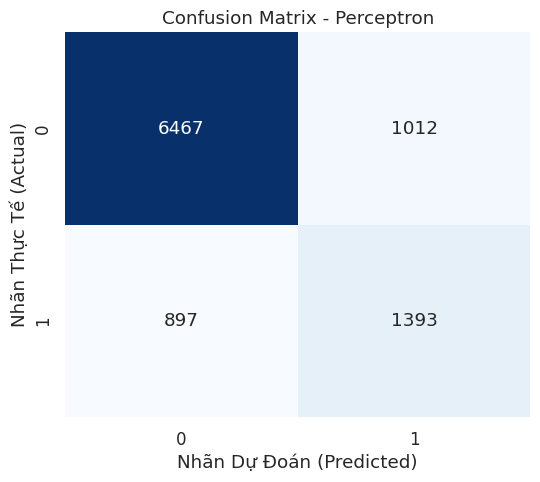

Accuracy: 0.8046

🔹 Gaussian Naive Bayes
Training: Gaussian Naive Bayes 
⏱️ Train time: 0.0114 seconds
📈 Độ chính xác (Accuracy) trên tập Test: 0.8126

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      7479
           1       0.68      0.39      0.49      2290

    accuracy                           0.81      9769
   macro avg       0.75      0.66      0.69      9769
weighted avg       0.80      0.81      0.79      9769



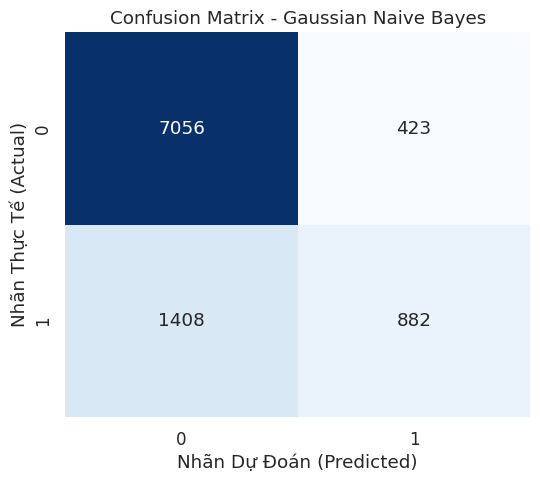

Accuracy: 0.8126

🔹 Linear SVM
Training: Linear SVM 
⏱️ Train time: 37.1616 seconds
📈 Độ chính xác (Accuracy) trên tập Test: 0.8569

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7479
           1       0.76      0.57      0.65      2290

    accuracy                           0.86      9769
   macro avg       0.82      0.76      0.78      9769
weighted avg       0.85      0.86      0.85      9769



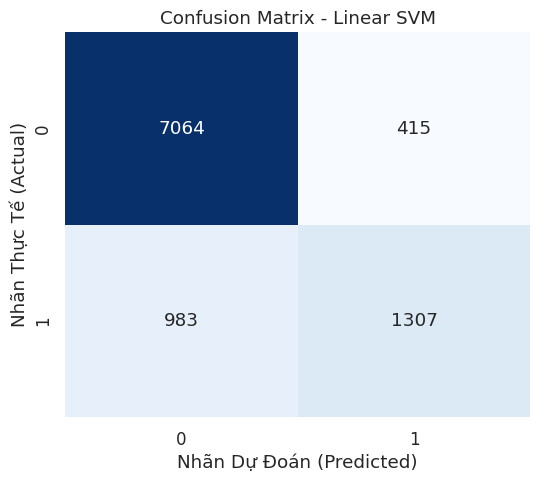

Accuracy: 0.8569

🔹 Radial SVM (RBF)
Training: RBF SVM 
⏱️ Train time: 32.6448 seconds
📈 Độ chính xác (Accuracy) trên tập Test: 0.8569

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7479
           1       0.76      0.57      0.65      2290

    accuracy                           0.86      9769
   macro avg       0.82      0.76      0.78      9769
weighted avg       0.85      0.86      0.85      9769



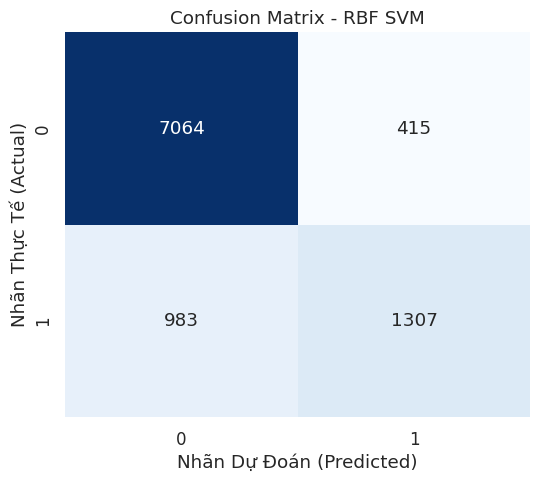

Accuracy: 0.8569

🔹 Random Forest
Training: Random Forest 
⏱️ Train time: 3.8538 seconds
📈 Độ chính xác (Accuracy) trên tập Test: 0.8627

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7479
           1       0.74      0.64      0.69      2290

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



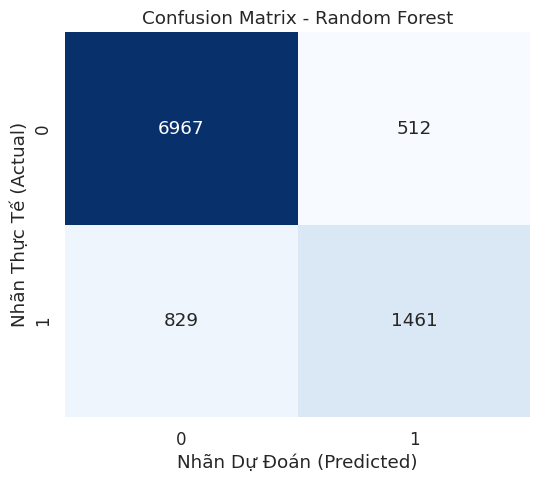

Accuracy: 0.8627

🔹 K-Nearest Neighbors
Training: K-Nearest Neighbors 
⏱️ Train time: 0.0640 seconds
📈 Độ chính xác (Accuracy) trên tập Test: 0.8366

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      7479
           1       0.67      0.61      0.64      2290

    accuracy                           0.84      9769
   macro avg       0.77      0.76      0.77      9769
weighted avg       0.83      0.84      0.83      9769



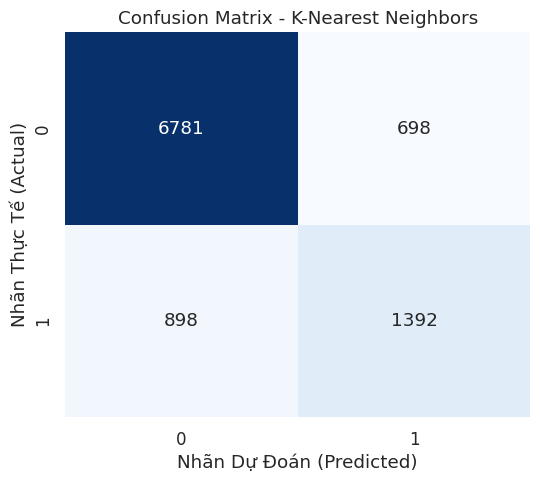

Accuracy: 0.8366


In [59]:
print("🎯 Đánh giá mô hình Perceptron...")

all_accuracies = {}

print("🔹 Perceptron")
acc_perceptron = evaluate_model(Perceptron(max_iter=1000, random_state=42), "Perceptron", X_train_sc, y_train, X_test_sc, y_test)
print(f"Accuracy: {acc_perceptron:.4f}")
all_accuracies['Perceptron'] = acc_perceptron

print("\n🔹 Gaussian Naive Bayes")
acc_gaussian = evaluate_model(GaussianNB(), "Gaussian Naive Bayes", X_train_sc, y_train, X_test_sc, y_test)
print(f"Accuracy: {acc_gaussian:.4f}")
all_accuracies['Gaussian Naive Bayes'] = acc_gaussian

print("\n🔹 Linear SVM")
acc_linear_svm = evaluate_model(SVC(random_state=42), "Linear SVM", X_train_sc, y_train, X_test_sc, y_test)
print(f"Accuracy: {acc_linear_svm:.4f}")
all_accuracies['Linear SVM'] = acc_linear_svm

print("\n🔹 Radial SVM (RBF)")
acc_rbf_svm = evaluate_model(SVC(kernel='rbf', random_state=42), "RBF SVM", X_train_sc, y_train, X_test_sc, y_test)
print(f"Accuracy: {acc_rbf_svm:.4f}")
all_accuracies['RBF SVM'] = acc_rbf_svm

print("\n🔹 Random Forest")
acc_random_forest = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest", X_train_sc, y_train, X_test_sc, y_test)
print(f"Accuracy: {acc_random_forest:.4f}")
all_accuracies['Random Forest'] = acc_random_forest

print("\n🔹 K-Nearest Neighbors")
acc_knn = evaluate_model(KNeighborsClassifier(n_neighbors=5), "K-Nearest Neighbors", X_train_sc, y_train, X_test_sc, y_test)
print(f"Accuracy: {acc_knn:.4f}")
all_accuracies['K-Nearest Neighbors'] = acc_knn



**Giải thích Ma trận Nhầm lẫn (Confusion Matrix):**

Ma trận nhầm lẫn 2x2 có cấu trúc:
```
                Predicted Negative  Predicted Positive
Actual Negative        TN                  FP
Actual Positive        FN                  TP
```

**Ý nghĩa các giá trị:**
- **TP (True Positive)**: Mô hình dự đoán Positive và thực tế là Positive (Đúng)
- **TN (True Negative)**: Mô hình dự đoán Negative và thực tế là Negative (Đúng)
- **FP (False Positive)**: Mô hình dự đoán Positive nhưng thực tế là Negative (Lỗi)
- **FN (False Negative)**: Mô hình dự đoán Negative nhưng thực tế là Positive (Lỗi)

**Các độ đo:**
- **Accuracy**: (TP + TN) / (TP + TN + FP + FN) - Tỷ lệ dự đoán đúng
- **Precision**: TP / (TP + FP) - Trong những dự đoán Positive, bao nhiêu % là đúng
- **Recall**: TP / (TP + FN) - Trong những trường hợp thực tế Positive, bao nhiêu % được phát hiện
- **F1-Score**: Trung bình hài hòa của Precision và Recall

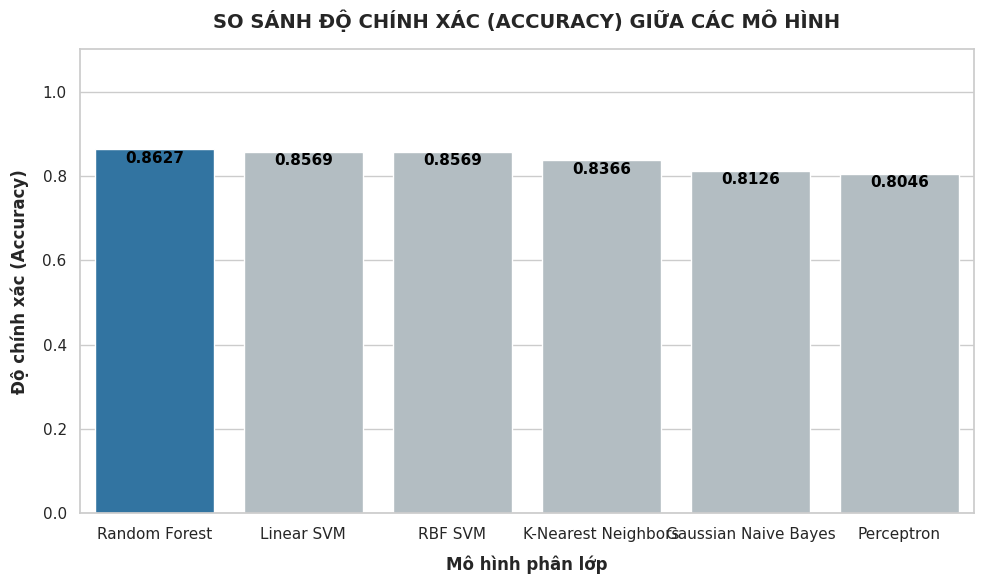

In [ ]:
sorted_acc = sorted(all_accuracies.items(), key=lambda x: x[1], reverse=True)
models, accuracies = zip(*sorted_acc)

# 2. Thiết kế giao diện biểu đồ
plt.figure(figsize=(10, 6))
# Thiết lập style nền trắng lưới xám sang trọng
sns.set_theme(style="whitegrid") 

# Tạo bảng màu: Màu xanh đậm làm điểm nhấn cho Random Forest, các mô hình khác màu xám nhẹ
colors = ['#1f77b4' if model == 'Random Forest' else '#b0bec5' for model in models]

# 3. Vẽ biểu đồ cột
ax = sns.barplot(x=list(models), y=list(accuracies), palette=colors, hue=list(models), legend=False)

# 4. Hiển thị giá trị Accuracy cụ thể trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height() - 0.05), # Vị trí chữ (hơi thấp hơn đỉnh cột một chút)
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='black')

plt.title('SO SÁNH ĐỘ CHÍNH XÁC (ACCURACY) GIỮA CÁC MÔ HÌNH', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mô hình phân lớp', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12, fontweight='bold', labelpad=10)

plt.ylim(0, 1.1) 

plt.tight_layout()
plt.show()

In [62]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances.index, importances.values, color='steelblue', alpha=0.85)

# Highlight top 3
for i, (val, bar) in enumerate(zip(importances.values, bars)):
    if i >= len(importances) - 3:
        bar.set_color('#E8625A')
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Mức Độ Quan Trọng (Gini Impurity Decrease)', fontsize=12, fontweight='bold')
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 đặc tính quan trọng nhất:")
print(importances.sort_values(ascending=False).head(5).round(4))

NameError: name 'best_rf' is not defined